### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = ''
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

>* Missing Data
>   * Car column is mostly null (only 108 non-null) and the five unique values.
>   * The purchase-history columns contain the rest of the nulls (Bar, Coffee, Togo, and Restaurants x2)
>     * 605 rows total
>     * 108-217 rows per column

>* Problem Data
>   * Car appears to be a text entry field with few entries and no consistency in content. I.e. low data quality

In [4]:
# Show the Columns, Row Count, Non-Null Count, and Types to check for missing and problem data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [5]:
# Show the numeric columns and their characteristics
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# Show the values for 'car' and their frequency
print(data.groupby(['car'])['car'].count())

car
Car that is too old to install Onstar :D    21
Mazda5                                      22
Scooter and motorcycle                      22
crossover                                   21
do not drive                                22
Name: car, dtype: int64


In [7]:
# Show the unique valus for purchase-history columns, excluding NaN which doesn't sort
def print_uniques(df,col):
  return print(col,':',df[col].dropna().sort_values().unique())

print_uniques(data,'Bar')
print_uniques(data,'CarryAway')
print_uniques(data,'CoffeeHouse')
print_uniques(data,'RestaurantLessThan20')
print_uniques(data,'Restaurant20To50')
print()
print_uniques(data,'destination')
print_uniques(data,'passanger')
print_uniques(data,'weather')
print_uniques(data,'coupon')
print_uniques(data,'age')
print_uniques(data,'maritalStatus')
#print_uniques(data,'occupation')
print_uniques(data,'income')

Bar : ['1~3' '4~8' 'gt8' 'less1' 'never']
CarryAway : ['1~3' '4~8' 'gt8' 'less1' 'never']
CoffeeHouse : ['1~3' '4~8' 'gt8' 'less1' 'never']
RestaurantLessThan20 : ['1~3' '4~8' 'gt8' 'less1' 'never']
Restaurant20To50 : ['1~3' '4~8' 'gt8' 'less1' 'never']

destination : ['Home' 'No Urgent Place' 'Work']
passanger : ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather : ['Rainy' 'Snowy' 'Sunny']
coupon : ['Bar' 'Carry out & Take away' 'Coffee House' 'Restaurant(20-50)'
 'Restaurant(<20)']
age : ['21' '26' '31' '36' '41' '46' '50plus' 'below21']
maritalStatus : ['Divorced' 'Married partner' 'Single' 'Unmarried partner' 'Widowed']
income : ['$100000 or More' '$12500 - $24999' '$25000 - $37499' '$37500 - $49999'
 '$50000 - $62499' '$62500 - $74999' '$75000 - $87499' '$87500 - $99999'
 'Less than $12500']


In [8]:
# Show the shape of the DataFrame if we remove the 'car' column and all remaining rows with NaN
tmp = data.drop('car',axis=1)
tmp = tmp.dropna()
tmp.shape

(12079, 25)

3. Decide what to do about your missing data -- drop, replace, other...

>* Decisions & Actions
>   * Drop the column 'car'
>   * Drop the null rows from the purchase-history columns (< 5%)
>   * Fix column 'passanger' by renaming to correct spelling (passenger with an e)

In [9]:
data_clean = data.drop('car',axis=1).dropna()
data_clean = data_clean.rename(columns={'passanger':'passenger'})

4. What proportion of the total observations chose to accept the coupon?



* 56.8433% of total observations chose to accept the coupon.
* 56.9335% of observations in the cleaned data set chose to accept the coupon.


In [10]:
# Calculate the proportion of total observations that chose to accept the coupon
proportion_all =  data['Y'].sum() / data['Y'].count()
proportion_clean = data_clean['Y'].sum() / data_clean['Y'].count()
diff_all_clean = abs(proportion_all - proportion_clean)
print(f"Proportion All: {proportion_all:.4%}")
print(f"Proportion Clean: {proportion_clean:.4%}")
print(f"Difference: {diff_all_clean:.4%}")

Proportion All: 56.8433%
Proportion Clean: 56.9335%
Difference: 0.0903%


5. Use a bar plot to visualize the `coupon` column.

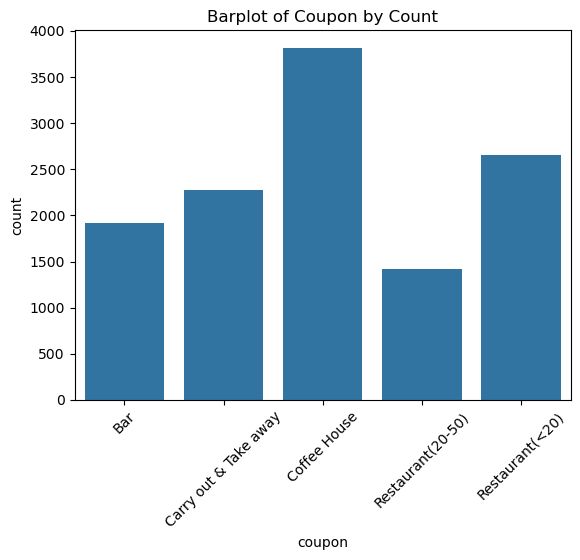

In [11]:
sns_result = ''
plt.xticks(rotation=45)
sns_result = sns.barplot(data_clean['coupon'].value_counts().sort_index()).set(title="Barplot of Coupon by Count")

6. Use a histogram to visualize the temperature column.

> * There are 3 values as describe in the data description, with counts skewing warmer.

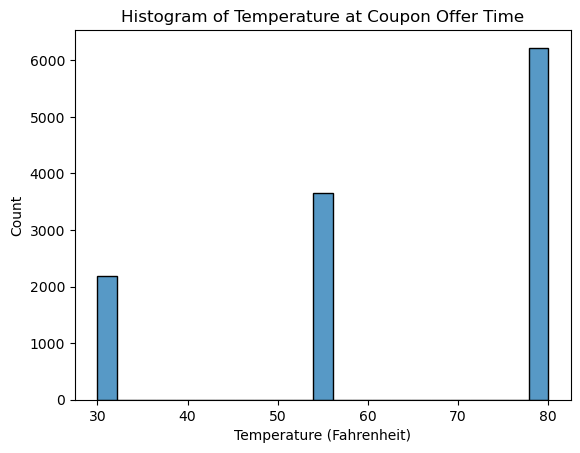

In [12]:
sns_result = ''
sns_axes = sns.histplot(data_clean, x='temperature')
sns_result = sns_axes.set(title="Histogram of Temperature at Coupon Offer Time",xlabel="Temperature (Fahrenheit)")

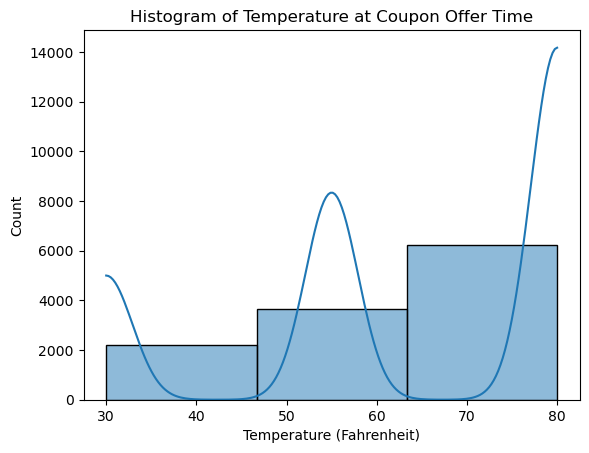

In [13]:
sns_result = ''
sns_axes = sns.histplot(data_clean, x='temperature',bins=3,kde=True)
sns_result = sns_axes.set(title="Histogram of Temperature at Coupon Offer Time",xlabel="Temperature (Fahrenheit)")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [14]:
coupons_bar = data_clean[data_clean['coupon'] == 'Bar']
print("data_clean.shape = ",data_clean.shape)
print("coupons_bar.shape = ",coupons_bar.shape)

data_clean.shape =  (12079, 25)
coupons_bar.shape =  (1913, 25)


2. What proportion of bar coupons were accepted?


In [15]:
proportion_bar =  coupons_bar['Y'].sum() / coupons_bar['Y'].count()
print(f"Bar Coupons Accepted: {proportion_bar:.4%}")

Bar Coupons Accepted: 41.1918%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


> * The rate of coupon acceptance among regular bar visitors (> 3 visits/month) was almost double that of less frequent bar visitors: 76% for regulars vs 37% for others.

In [16]:
proportion_bar_lte3 =  coupons_bar.query("Bar in ['never','less1','1~3']")['Y'].sum() / coupons_bar.query("Bar in ['never','less1','1~3']")['Y'].count()
print(f"Bar Coupons Accepted (Bar Visits <= 3): {proportion_bar_lte3:.4%}")
proportion_bar_gt3 =  coupons_bar.query("Bar in ['4~8','gt8']")['Y'].sum() / coupons_bar.query("Bar in ['4~8','gt8']")['Y'].count()
print(f"Bar Coupons Accepted (Bar Visits > 3): {proportion_bar_gt3:.4%}")

Bar Coupons Accepted (Bar Visits <= 3): 37.2674%
Bar Coupons Accepted (Bar Visits > 3): 76.1658%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


> * Limiting the age and lessening the regularity reduced acceptance rate to ~69%, down 7 points from the earlier test.

In [17]:
accepted_bar_gt1and25 = coupons_bar.query("Bar not in ['never','less1'] and age in ['26','31','36','41','46','50plus']")['Y'].sum()
offered_bar_gt1and25 = coupons_bar.query("Bar not in ['never','less1'] and age in ['26','31','36','41','46','50plus']")['Y'].count()
proportion_bar_gt1and25 = accepted_bar_gt1and25 / offered_bar_gt1and25
print(f"Bar Coupons Accepted (Bar Visits > 1 and Age <= 25): {accepted_bar_gt1and25}")
print(f"Bar Coupons Offered (Bar Visits > 1 and Age <= 25): {offered_bar_gt1and25}")
print(f"Bar Coupons Accepted (Bar Visits > 1 and Age <= 25): {proportion_bar_gt1and25:.4%}")

Bar Coupons Accepted (Bar Visits > 1 and Age <= 25): 278
Bar Coupons Offered (Bar Visits > 1 and Age <= 25): 403
Bar Coupons Accepted (Bar Visits > 1 and Age <= 25): 68.9826%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [18]:
accepted_bar_gt1_pass_occ = coupons_bar.query("Bar not in ['never','less1'] & passenger in ['Partner','Friend(s)'] & occupation not in ['Farming Fishing & Forestry']")['Y'].sum()
offered_bar_gt1_pass_occ = coupons_bar.query("Bar not in ['never','less1'] & passenger in ['Partner','Friend(s)'] & occupation not in ['Farming Fishing & Forestry']")['Y'].count()
proportion_bar_gt1_pass_occ = accepted_bar_gt1_pass_occ / offered_bar_gt1_pass_occ
print("Where Visits > 1, Passenger is Friend/Partner, and Occupation is not Farming Fishing & Forestry")
print(f"* Bar Coupons Accepted: {accepted_bar_gt1_pass_occ}")
print(f"* Bar Coupons Offered: {offered_bar_gt1_pass_occ}")
print(f"* Bar Coupons Acceptance Rate: {proportion_bar_gt1_pass_occ:.1%}")

Where Visits > 1, Passenger is Friend/Partner, and Occupation is not Farming Fishing & Forestry
* Bar Coupons Accepted: 135
* Bar Coupons Offered: 189
* Bar Coupons Acceptance Rate: 71.4%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [19]:
def print_acceptance_rate(df,query_string,query_name,df_name):
  # Given a DataFrame and conditions, find the acceptance rate.
  accepted = df.query(query_string)['Y'].sum()
  offered = df.query(query_string)['Y'].count()
  proportion = accepted / offered
  print(query_name)
  print(f"* {df_name} Accepted: {accepted}")
  print(f"* {df_name} Offered: {offered}")
  return print(f"* {df_name} Acceptance Rate: {proportion:.1%}")

#Find the individual acceptance rates for each of the 3 conditions in problem 6, then find the combined acceptance rate.
condition1 = "(Bar not in ['never','less1'] & passenger in ['Partner','Friend(s)'] & maritalStatus not in ['Widowed'])"
condition2 = "(Bar not in ['never','less1'] & age in ['below21','21','26'])"
condition3 = "(RestaurantLessThan20 in ['4~8','gt8'] & income in ['$12500 - $24999','$25000 - $37499','$37500 - $49999','Less than $12500'])"
conditions = '|'.join([condition1, condition2, condition3])
print_acceptance_rate(coupons_bar,condition1,condition1,"Bar Coupons")
print_acceptance_rate(coupons_bar,condition2,condition2,"Bar Coupons")
print_acceptance_rate(coupons_bar,condition3,condition3,"Bar Coupons")
print()
print_acceptance_rate(coupons_bar,conditions,"Not Widowed w/ Adult Passenger OR Under Age 30 OR regular at Cheap Restaurants w/ Income < 50k","Bar Coupons")

(Bar not in ['never','less1'] & passenger in ['Partner','Friend(s)'] & maritalStatus not in ['Widowed'])
* Bar Coupons Accepted: 135
* Bar Coupons Offered: 189
* Bar Coupons Acceptance Rate: 71.4%
(Bar not in ['never','less1'] & age in ['below21','21','26'])
* Bar Coupons Accepted: 236
* Bar Coupons Offered: 328
* Bar Coupons Acceptance Rate: 72.0%
(RestaurantLessThan20 in ['4~8','gt8'] & income in ['$12500 - $24999','$25000 - $37499','$37500 - $49999','Less than $12500'])
* Bar Coupons Accepted: 152
* Bar Coupons Offered: 333
* Bar Coupons Acceptance Rate: 45.6%

Not Widowed w/ Adult Passenger OR Under Age 30 OR regular at Cheap Restaurants w/ Income < 50k
* Bar Coupons Accepted: 360
* Bar Coupons Offered: 635
* Bar Coupons Acceptance Rate: 56.7%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

> Based on these observations, I hypothesize that age <br>
> and bar regularity are the primary drivers of Bar Coupon acceptance.


Based on these observations, I hypothesize that age 
and bar regularity are the primary drivers of Bar Coupon acceptance.



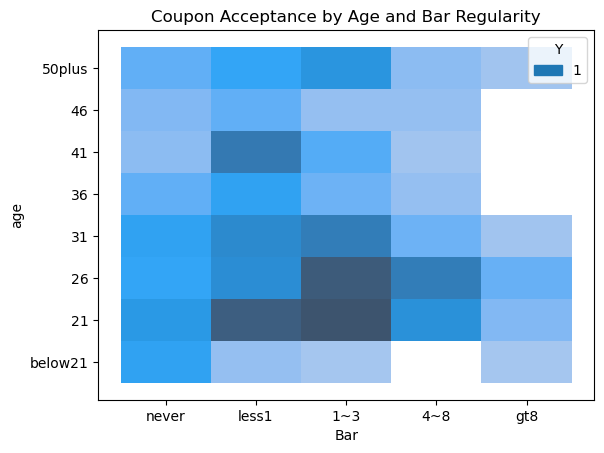

In [20]:
#Create a heatmap histogram to narrow our focus on participants most likely to acces the Bar coupon
order_freq = ['never','less1','1~3','4~8','gt8']
order_age = ['below21','21','26','31','36','41','46','50plus'][::-1]
cb2 = coupons_bar.copy()
cb2['Bar'] = pd.Categorical(cb2['Bar'],categories=order_freq,ordered=True)
cb2['age'] = pd.Categorical(cb2['age'],categories=order_age,ordered=True)
print("\nBased on these observations, I hypothesize that age \nand bar regularity are the primary drivers of Bar Coupon acceptance.\n")
sns_result = sns.histplot(cb2[cb2['Y'] == 1],x='Bar',y='age',hue='Y').set(title="Coupon Acceptance by Age and Bar Regularity")

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

> Today I will explore the acceptance of "Carry out & Take away" coupons. <br>
> * I'll use "To Go" (or "togo" in the code) as shorthand for "Carry out & Take away"
> * I will investigate how Age, Passenger, Time of Day, Weather, and Direction (Same) determine the characteristics of passengers who accept coupons.

In [21]:
coupons_togo = data_clean[data_clean['coupon'] == 'Carry out & Take away']
coupons_togo_sorted = coupons_togo.copy()
coupons_togo.shape

(2280, 25)

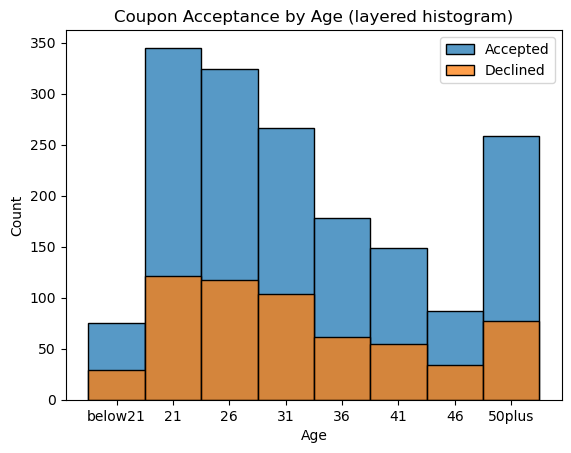

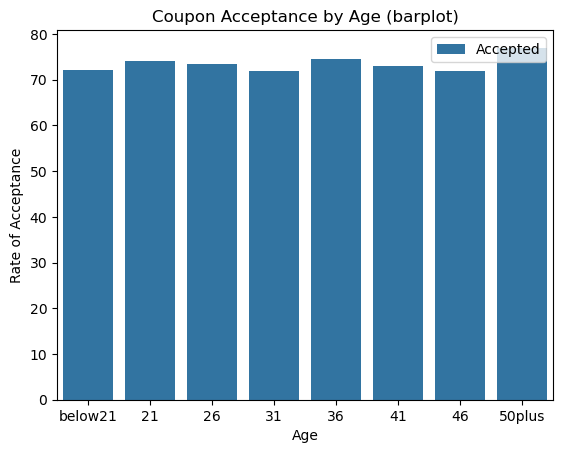

,age,acceptance
0,below21,72.115385
1,21,74.034335
2,26,73.469388
3,31,71.891892
4,36,74.476987
5,41,73.039216
6,46,71.900826
7,50plus,77.014925


In [22]:
# Let's define the parameter we are working with
current_col = 'age'
current_title = 'Coupon Acceptance by Age'
current_xtitle = "Age"
order_age_asc = order_age[::-1]
coupons_togo_sorted[current_col] = pd.Categorical(coupons_togo['age'],categories=order_age_asc,ordered=True)

# Let's see the balance of acceptances and declines.
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 1],x=current_col,label='Accepted')
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 0],x=current_col,label='Declined')
sns_result.legend(loc='upper right')
plt_result = plt.title(current_title + ' (layered histogram)')
plt_result = plt.xlabel(current_xtitle)
plt.show()

# What's the acceptance rate by group?
coupons_togo_sum = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].sum()
coupons_togo_count = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].count()
coupons_togo_acceptance = (coupons_togo_sum / coupons_togo_count)*100
coupons_togo_acceptance = coupons_togo_acceptance.reset_index()
coupons_togo_acceptance = coupons_togo_acceptance.rename(columns={'Y':'acceptance'})
coupons_togo_acceptance = pd.DataFrame(coupons_togo_acceptance)
sns_result = sns.barplot(coupons_togo_acceptance,x=current_col,y='acceptance',label='Accepted')
plt_result = plt.title(current_title + ' (barplot)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.ylabel('Rate of Acceptance')
plt.show()
coupons_togo_acceptance

#### Age as a determinant for To Go coupon acceptance
 * While there are more participants in the 21-30 year old and 50-plus brackets, acceptance rates across all ages are between 71.8% and 77.1%, a range of only 5.3 percentage points. There does not appear to be a significant pattern based on the current age groupings.

Let's see if having children makes a difference.

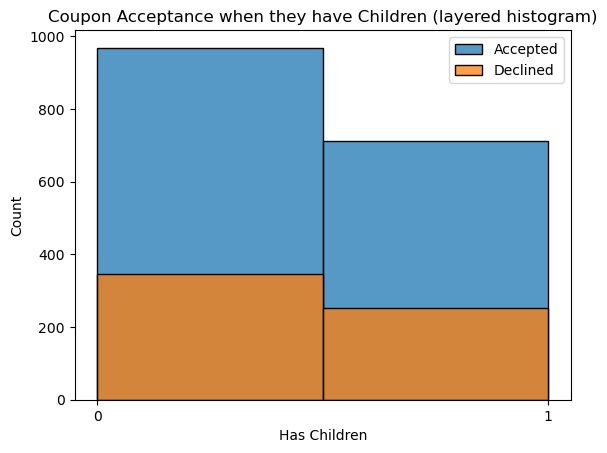

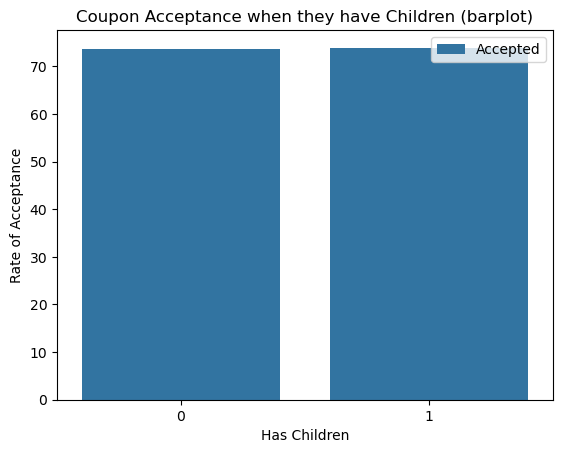

,has_children,acceptance
0,0,73.688213
1,1,73.886010


In [23]:
# Let's define the parameter we are working with
current_col = 'has_children'
current_title = 'Coupon Acceptance when they have Children'
current_xtitle = "Has Children"

# Let's see the balance of acceptances and declines.
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 1],x=current_col,label='Accepted',bins=2)
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 0],x=current_col,label='Declined',bins=2)
sns_result.legend(loc='upper right')
plt_result = plt.title(current_title + ' (layered histogram)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.xticks([False,True])
plt.show()

# What's the acceptance rate by group?
coupons_togo_sum = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].sum()
coupons_togo_count = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].count()
coupons_togo_acceptance = (coupons_togo_sum / coupons_togo_count)*100
coupons_togo_acceptance = coupons_togo_acceptance.reset_index()
coupons_togo_acceptance = coupons_togo_acceptance.rename(columns={'Y':'acceptance'})
coupons_togo_acceptance = pd.DataFrame(coupons_togo_acceptance)
sns_result = sns.barplot(coupons_togo_acceptance,x=current_col,y='acceptance',label='Accepted')
plt_result = plt.title(current_title + ' (barplot)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.ylabel('Rate of Acceptance')
plt.show()
coupons_togo_acceptance

#### Having Children as a determinant for To Go coupon acceptance
* Wow. Nearly identical acceptance rates whether or not children are in the family.

Let's see if marital status makes a difference.

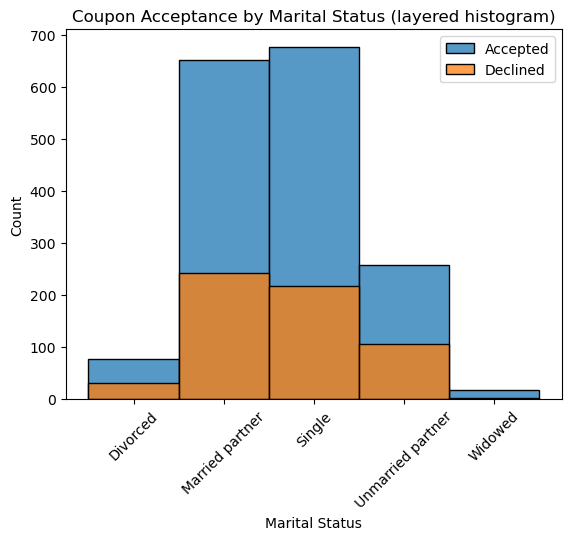

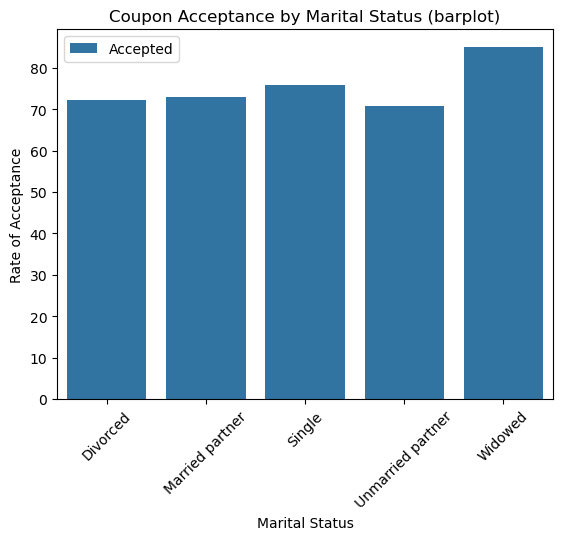

,maritalStatus,acceptance
0,Divorced,72.222222
1,Married partner,72.930649
2,Single,75.727069
3,Unmarried partner,70.879121
4,Widowed,85.000000


In [24]:
# Let's define the parameter we are working with
current_col = 'maritalStatus'
current_title = 'Coupon Acceptance by Marital Status'
current_xtitle = "Marital Status"
order_marital = coupons_togo[current_col].sort_values().unique()
coupons_togo_sorted[current_col] = pd.Categorical(coupons_togo[current_col],categories=order_marital,ordered=True)

# Let's see the balance of acceptances and declines.
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 1],x=current_col,label='Accepted')
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 0],x=current_col,label='Declined')
sns_result.legend(loc='upper right')
plt.title(current_title + ' (layered histogram)')
plt.xlabel(current_xtitle)
plt.xticks(rotation=45)
plt.show()

# What's the acceptance rate by group?
coupons_togo_sum = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].sum()
coupons_togo_count = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].count()
coupons_togo_acceptance = (coupons_togo_sum / coupons_togo_count)*100
coupons_togo_acceptance = coupons_togo_acceptance.reset_index()
coupons_togo_acceptance = coupons_togo_acceptance.rename(columns={'Y':'acceptance'})
coupons_togo_acceptance = pd.DataFrame(coupons_togo_acceptance)
sns_result = sns.barplot(coupons_togo_acceptance,x=current_col,y='acceptance',label='Accepted')
plt.title(current_title + ' (barplot)')
plt.xlabel(current_xtitle)
plt.ylabel('Rate of Acceptance')
plt.xticks(rotation=45)
plt.show()
coupons_togo_acceptance

#### Marital Status as a determinant for To Go coupon acceptance
* While the acceptance rate is consistently high, there's a small increate in acceptance for single individuals, and a big 10 percentage point bump for widowed individuals.

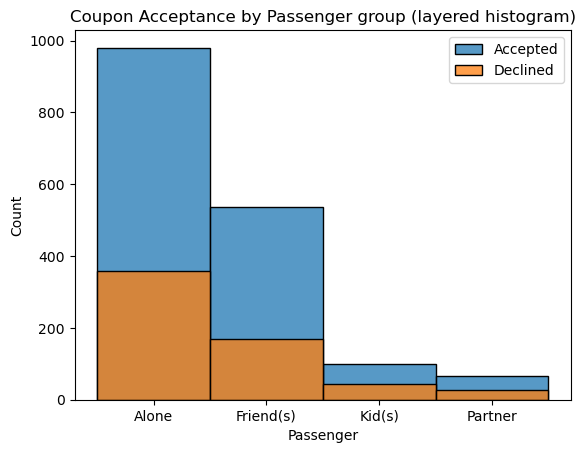

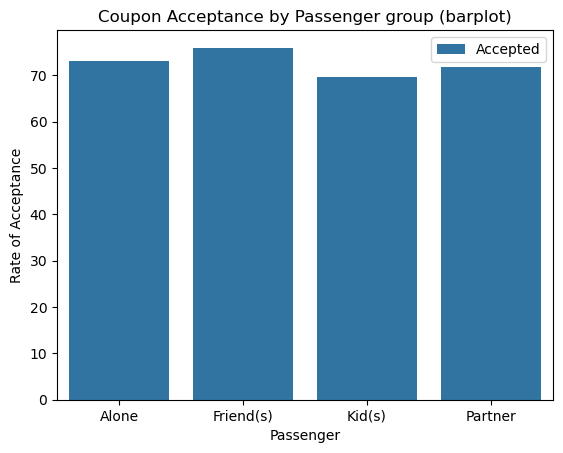

,passenger,acceptance
0,Alone,73.188947
1,Friend(s),75.954738
2,Kid(s),69.718310
3,Partner,71.739130


In [25]:
# Let's define the parameter we are working with
current_col = 'passenger'
current_title = 'Coupon Acceptance by Passenger group'
current_xtitle = "Passenger"
order_pass = coupons_togo[current_col].sort_values().unique()
coupons_togo_sorted[current_col] = pd.Categorical(coupons_togo[current_col],categories=order_pass,ordered=True)

# Let's see the balance of acceptances and declines.
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 1],x=current_col,label='Accepted')
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 0],x=current_col,label='Declined')
sns_result.legend(loc='upper right')
plt_result = plt.title(current_title + ' (layered histogram)')
plt_result = plt.xlabel(current_xtitle)
plt.show()

# What's the acceptance rate by group?
coupons_togo_sum = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].sum()
coupons_togo_count = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].count()
coupons_togo_acceptance = (coupons_togo_sum / coupons_togo_count)*100
coupons_togo_acceptance = coupons_togo_acceptance.reset_index()
coupons_togo_acceptance = coupons_togo_acceptance.rename(columns={'Y':'acceptance'})
coupons_togo_acceptance = pd.DataFrame(coupons_togo_acceptance)
sns_result = sns.barplot(coupons_togo_acceptance,x=current_col,y='acceptance',label='Accepted')
plt_result = plt.title(current_title + ' (barplot)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.ylabel('Rate of Acceptance')
plt.show()
coupons_togo_acceptance

#### Passengers as a determinant for To Go coupon acceptance
* Acceptance rates for all categories are high, but there seems to be a slight penalty for having Kids in the car. Intuition tells me there might be an issue of distraction in the Kids as passengers case.

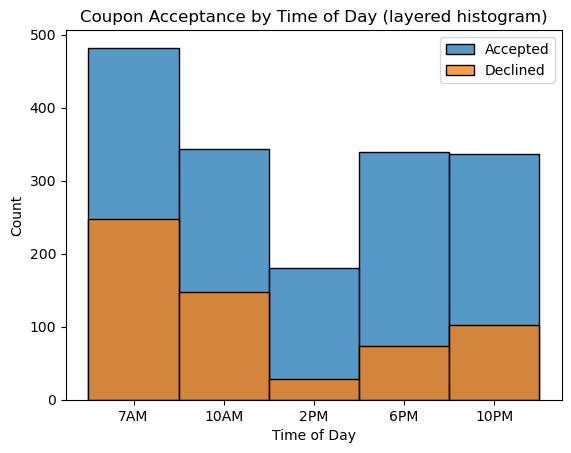

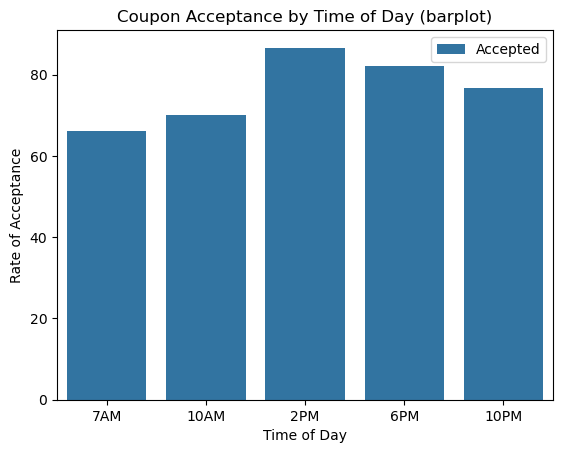

,time,acceptance
0,7AM,66.117970
1,10AM,70.000000
2,2PM,86.602871
3,6PM,82.082324
4,10PM,76.765376


In [26]:
# Let's define the parameter we are working with
current_col = 'time'
current_title = 'Coupon Acceptance by Time of Day'
current_xtitle = "Time of Day"
order_time = order_freq = ['7AM','10AM','2PM','6PM','10PM']
coupons_togo_sorted[current_col] = pd.Categorical(coupons_togo[current_col],categories=order_time,ordered=True)

# Let's see the balance of acceptances and declines.
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 1],x=current_col,label='Accepted')
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 0],x=current_col,label='Declined')
sns_result.legend(loc='upper right')
plt_result = plt.title(current_title + ' (layered histogram)')
plt_result = plt.xlabel(current_xtitle)
plt.show()

# What's the acceptance rate by group?
coupons_togo_sum = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].sum()
coupons_togo_count = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].count()
coupons_togo_acceptance = (coupons_togo_sum / coupons_togo_count)*100
coupons_togo_acceptance = coupons_togo_acceptance.reset_index()
coupons_togo_acceptance = coupons_togo_acceptance.rename(columns={'Y':'acceptance'})
coupons_togo_acceptance = pd.DataFrame(coupons_togo_acceptance)
sns_result = sns.barplot(coupons_togo_acceptance,x=current_col,y='acceptance',label='Accepted')
plt_result = plt.title(current_title + ' (barplot)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.ylabel('Rate of Acceptance')
plt.show()
coupons_togo_acceptance

#### Time of Day as a determinant for To Go coupon acceptance
* Again, the acceptance rates are high, and there is a boost towards the end of the day (presumably toward dinner time).
* Further investigation could break this boost out to see if there is a lunch and dinner split. Lunch is difficult to measure as the 2PM bucket may include both lunch and dinner. Smaller buckets would give a clearer picture of trends during the day.

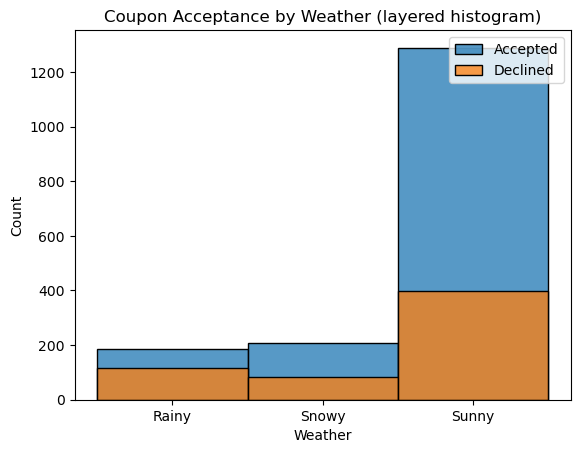

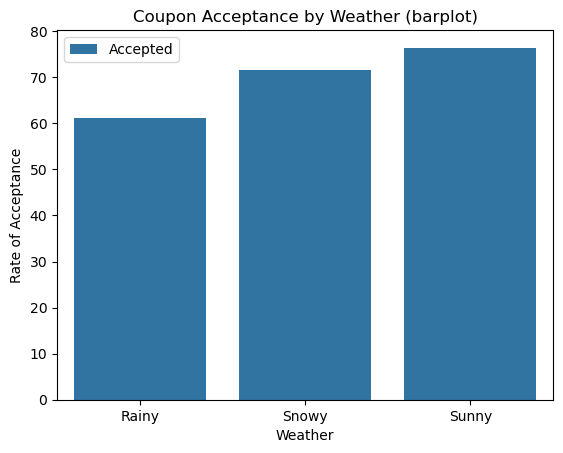

,weather,acceptance
0,Rainy,61.129568
1,Snowy,71.575342
2,Sunny,76.407825


In [27]:
# Let's define the parameter we are working with
current_col = 'weather'
current_title = 'Coupon Acceptance by Weather'
current_xtitle = "Weather"
order_weather = coupons_togo[current_col].sort_values().unique()
coupons_togo_sorted[current_col] = pd.Categorical(coupons_togo[current_col],categories=order_weather,ordered=True)

# Let's see the balance of acceptances and declines.
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 1],x=current_col,label='Accepted')
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 0],x=current_col,label='Declined')
sns_result.legend(loc='upper right')
plt_result = plt.title(current_title + ' (layered histogram)')
plt_result = plt.xlabel(current_xtitle)
plt.show()

# What's the acceptance rate by group?
coupons_togo_sum = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].sum()
coupons_togo_count = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].count()
coupons_togo_acceptance = (coupons_togo_sum / coupons_togo_count)*100
coupons_togo_acceptance = coupons_togo_acceptance.reset_index()
coupons_togo_acceptance = coupons_togo_acceptance.rename(columns={'Y':'acceptance'})
coupons_togo_acceptance = pd.DataFrame(coupons_togo_acceptance)
sns_result = sns.barplot(coupons_togo_acceptance,x=current_col,y='acceptance',label='Accepted')
plt_result = plt.title(current_title + ' (barplot)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.ylabel('Rate of Acceptance')
plt.show()
coupons_togo_acceptance

#### Weather as a determinant for To Go coupon acceptance
* Again, the acceptance rates are high.
* I'm surprised to see Snowy come out ahead of Rainy for acceptance.
* Sunny leads the way, 5% better than Snowy, and a whole 15% better than Rainy

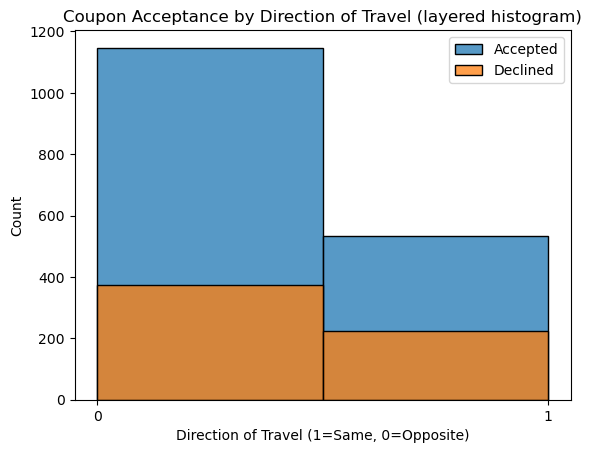

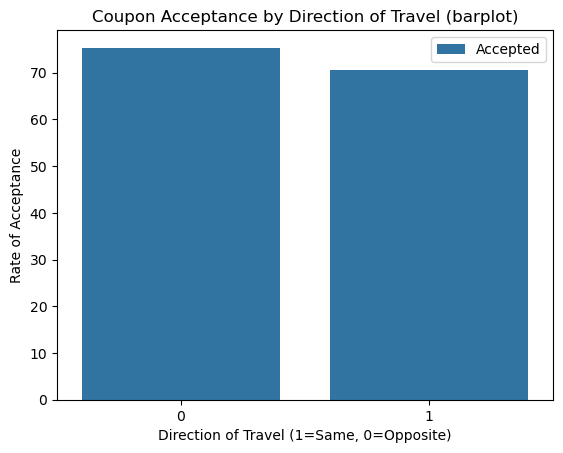

,direction_same,acceptance
0,0,75.361367
1,1,70.580475


In [28]:

# Let's define the parameter we are working with
current_col = 'direction_same'
current_title = 'Coupon Acceptance by Direction of Travel'
current_xtitle = "Direction of Travel (1=Same, 0=Opposite)"

# Let's see the balance of acceptances and declines.
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 1],x=current_col,label='Accepted',bins=2)
sns_result = sns.histplot(coupons_togo_sorted[coupons_togo['Y'] == 0],x=current_col,label='Declined',bins=2)
sns_result.legend(loc='upper right')
plt_result = plt.title(current_title + ' (layered histogram)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.xticks([False,True])
plt.show()

# What's the acceptance rate by group?
coupons_togo_sum = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].sum()
coupons_togo_count = coupons_togo_sorted.groupby([current_col],observed=False)['Y'].count()
coupons_togo_acceptance = (coupons_togo_sum / coupons_togo_count)*100
coupons_togo_acceptance = coupons_togo_acceptance.reset_index()
coupons_togo_acceptance = coupons_togo_acceptance.rename(columns={'Y':'acceptance'})
coupons_togo_acceptance = pd.DataFrame(coupons_togo_acceptance)
sns_result = sns.barplot(coupons_togo_acceptance,x=current_col,y='acceptance',label='Accepted')
plt_result = plt.title(current_title + ' (barplot)')
plt_result = plt.xlabel(current_xtitle)
plt_result = plt.ylabel('Rate of Acceptance')
plt.show()
coupons_togo_acceptance

#### Direction of Travel as a determinant for To Go coupon acceptance
* There something here as driving in the opposite direction gives a 5% higher acceptance rate than driving in the same direction.
* Most coupons are offered to drivers in the opposite direction.
* Is this because of offer timing, visible signage on the road, or some other metric that correlates with direction? All possible areas for further investigation.

## Conclusion
* Being single (including widowed), with friends, and ahead of dinner time are the big indicators of higher To Go coupon acceptance.
* That said, most coupons are accepted, and as long as it isn't rainy you can expect a 70% acceptance rate from most individuals for To Go food.

## Recommendations and Next Steps
* Rather than looking at who accepts a coupon, let's look at how coupons can shift behavior for participants.
* Advertisers are looking to influence behavior when they buy advertising like coupons.
* Here are some scenarios to investigate:
  * How coupon offerings make activities more attractive to participants.
  * How coupon offerings make specific advertisers more attractive to participants.